# Projekt 6: Problem wieloagentowy – Gra Makao

**Autorzy**: Kalina Rączka, Emilia Sarna

**Data**: 17.06.2026

### Opis środowiska – gra karciana Makao

Makao to polska gra karciana, rozgrywana przez 4 graczy przy użyciu standardowej talii 52 kart. Cel gry: jako pierwszy opróżnić rękę z kart.

**Reguły podstawowe:**
- Na początku każdy gracz otrzymuje 5 kart
- W swojej kolejce gracz może zagrać kartę pasującą kolorem lub rangą do wierzchniej karty stosu odrzutów, albo dobrać kartę ze stosu

**Karty specjalne:**

| Karta | Efekt |
|-------|-------|
| 2 | Następny gracz dobiera 2 karty (stackowalny) |
| 3 | Następny gracz dobiera 3 karty (stackowalny) |
| 4 | Następny gracz pomija turę |
| Walet (J) | Gracz żąda określonej rangi |
| Dama (Q) | Dzika, zawsze grywalna |
| As (A) | Gracz żąda określonego koloru |
| Król Pik (K♠) | Następny gracz dobiera 5 kart |
| Król Kier (K♥) | Poprzedni gracz dobiera 5 kart |

Środowisko zostało zaimplementowane jako własne środowisko wieloagentowe w oparciu o interfejs **PettingZoo AEC** (Agent Environment Cycle), w którym agenci wykonują akcje naprzemiennie.

### Implementacja środowiska Makao

**Przestrzeń obserwacji:** Wektor 67 floatów zakodowany dla aktualnego agenta:

| Zakres | Rozmiar | Zawartość |
|--------|---------|----------|
| [0:52] | 52 | Ręka agenta – multi-hot (1 = karta w ręce) |
| [52:54] | 2 | Wierzchnia karta: ranga/12, kolor/3 |
| [54:55] | 1 | Penalny dobór / 10 |
| [55:56] | 1 | Flaga pominięcia tury |
| [56:58] | 2 | Żądany kolor / 3, żądana ranga / 12 (lub −1) |
| [58:62] | 4 | Liczba kart rywali / 52, rozmiar stosu / 52 |
| [62:67] | 5 | Własna liczba kart + pozycja |

**Przestrzeń akcji:** `Discrete(54)` – akcje 0–51 to zagranie karty o danym indeksie, akcja 52 to dobranie karty, akcja 53 to pas (akceptacja pominięcia tury).

Indeks karty = `rank_idx * 4 + suit_idx`, gdzie rangi są numerowane od 0 (2) do 12 (As), a kolory od 0 (Trefl) do 3 (Pik).

In [ ]:
def action_mask(self):
    agent = self.agent_selection
    mask = np.zeros(54, dtype=np.int8)
    hand = self._hands.get(agent, set())
    top = self._discard[-1]
    top_rank = card_rank(top)
    top_suit = card_suit(top)

    if self._skip_next:
        mask[ACTION_PASS] = 1
        return mask

    if self._pending_draw > 0:
        # Można kontynuować serię 2/3 lub K pik
        for c in hand:
            r = card_rank(c)
            if top_rank in (RANK_2, RANK_3) and r in (RANK_2, RANK_3):
                mask[c] = 1
            elif top_rank == RANK_KING and r == RANK_KING and card_suit(c) == SUIT_SPADES:
                mask[c] = 1
        if mask[:52].sum() == 0:
            mask[ACTION_DRAW] = 1
        return mask

    for c in hand:
        r = card_rank(c)
        s = card_suit(c)
        if r == RANK_QUEEN:           # Dama zawsze grywalna
            mask[c] = 1
            continue
        if self._requested_suit is not None:
            if s == self._requested_suit or r == RANK_ACE:
                mask[c] = 1
        elif self._requested_rank is not None:
            if r == self._requested_rank or r == RANK_JACK:
                mask[c] = 1
        else:
            if s == top_suit or r == top_rank:  # pasujący kolor lub ranga
                mask[c] = 1
    mask[ACTION_DRAW] = 1
    return mask

**Schemat nagród:**

| Zdarzenie | Nagroda |
|-----------|--------|
| Wygrana (pusta ręka) | +20.0 |
| Przegrana (inny wygrał) | −2.0 |
| Zagranie karty (bazowo) | +0.4 |
| Bonus za rękę 1-kartową | +1.5 |
| Bonus za rękę ≤3 kart | +0.5 |
| Zagranie karty specjalnej | +0.5 |
| Za każdą kartę dobieraną przez rywala (2/3/K♠/K♥) | +0.3/kartę |
| Przewaga liczbowa nad rywalami | +(avg\_opp − own) × 0.04 |
| Dobieranie gdy można grać | −0.4 |
| Dobieranie wymuszone (penalny) | −0.05/kartę |
| Pominięcie tury | −0.05 |
| Kara za krok (efektywność) | −0.003 |

## Algorytmy

Do rozwiązania problemu zostały użyte dwa algorytmy: MaskablePPO (w dwóch wariantach wartości hiperparametrów) i TRPO.

In [1]:
def _lr_schedule(initial_lr):
    def func(progress_remaining):
        return max(initial_lr * progress_remaining, initial_lr / 10)
    return func

ALGO_CONFIGS = {
    "ppo_a": ("MaskablePPO", True, dict(
        learning_rate=_lr_schedule(3e-4),
        n_steps=4096, batch_size=512, n_epochs=10,
        gamma=0.997, gae_lambda=0.95, ent_coef=0.05, clip_range=0.2,
        policy_kwargs={"net_arch": [256, 256]},
    )),
    "ppo_b": ("MaskablePPO", True, dict(
        learning_rate=_lr_schedule(5e-4),
        n_steps=2048, batch_size=256, n_epochs=6,
        gamma=0.99, gae_lambda=0.92, ent_coef=0.1, clip_range=0.25,
        policy_kwargs={"net_arch": [128, 128]},
    )),
    "trpo": ("TRPO", False, dict(
        learning_rate=_lr_schedule(1e-3),
        n_steps=2048, batch_size=256,
        gamma=0.99, gae_lambda=0.95, target_kl=0.01, n_critic_updates=10,
        policy_kwargs={"net_arch": [128, 128]},
    )),
}

import pandas as pd
rows = []
lr_map = {"ppo_a": "3e-4", "ppo_b": "5e-4", "trpo": "1e-3"}
for name, (algo, use_mask, cfg) in ALGO_CONFIGS.items():
    row = {"Konfiguracja": name.upper(), "Algorytm": algo, "Masking": "tak" if use_mask else "nie"}
    row["lr_start"] = lr_map[name]
    row["n_steps"] = cfg["n_steps"]
    row["gamma"] = cfg["gamma"]
    row["sieć"] = str(cfg["policy_kwargs"]["net_arch"])
    rows.append(row)

df = pd.DataFrame(rows).set_index("Konfiguracja")
print(df.to_string())

                 Algorytm Masking lr_start  n_steps  gamma        sieć
Konfiguracja                                                          
PPO_A         MaskablePPO     tak     3e-4     4096  0.997  [256, 256]
PPO_B         MaskablePPO     tak     5e-4     2048  0.990  [128, 128]
TRPO                 TRPO     nie     1e-3     2048  0.990  [128, 128]


### Wyniki – krzywe uczenia

Wszystkie modele były trenowane przez 500 tysięcy kroków z 4 równoległymi środowiskami. Rywale (player_1–3) używali zachłannej losowej strategii (zawsze grają kartę jeśli mogą). Krzywe uczenia przedstawiają nagrodę epizodową zdobytą przez player_0.

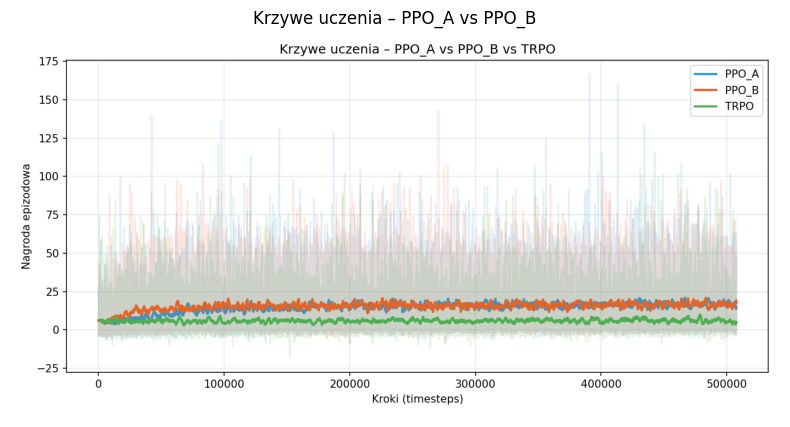

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

curve_path = "results/plots/learning_curves.png"

img = mpimg.imread(curve_path)
plt.figure(figsize=(12, 5))
plt.imshow(img)
plt.axis("off")
plt.title("Krzywe uczenia – PPO_A vs PPO_B")
plt.show()

**Analiza krzywych uczenia:**

- Przez pierwsze 50 tysięcy kroków PPO_A i TRPO uczą się dość podobnie, praktycznie w ogóle nie poprawiając swoich wyników, wyróżnia się natomiast PP_B.
- Około 100 tysięcznego kroku PPO_A doścignęło PPO_B i oba utrzymują nie poprawiają już swoich wyników.
- TRPO poradził sobie zdecydowanie najgorzej - praktycznie nic się nie nauczył.

### Ewaluacja – win rate

Zostały wykonane także eksperymenty związane z przeciwstawieniem agentów wobec siebie nawzajem. Każdą konfigurację rozegrano 200 razy.

In [ ]:
import json, os
import numpy as np

eval_path = "results/eval_results.json"
with open(eval_path) as f:
    results = json.load(f)

CONFIGS = ("ppo_a", "ppo_b", "trpo")
LABELS  = {"ppo_a": "PPO_A", "ppo_b": "PPO_B", "trpo": "TRPO"}

print("=" * 55)
bl = results.get("baseline_random", {})
avg_bl = np.mean(list(bl.get("win_rates", {}).values()))
print(f"BASELINE losowy:  avg win rate = {avg_bl:.1%}  | timeouty: {bl.get('timeouts', '?')}")

for cfg in CONFIGS:
    j  = results.get(f"{cfg}_jednorodny")
    vr = results.get(f"{cfg}_vs_random")
    if not j:
        continue
    avg_j = np.mean(list(j["win_rates"].values()))
    print(f"\n{LABELS[cfg]:6s}  jednorodny  avg/agent = {avg_j:.1%}  | timeouty: {j['timeouts']}")
    if vr:
        print(f"       vs losowy   model  = {vr['model_win_rate']:.1%}  |"
                f" losowy = {vr['random_win_rate']:.1%}  | timeouty: {vr['timeouts']}")

print("\n" + "=" * 55)
print("MODEL vs MODEL – konfrontacje bezpośrednie (2v2):")
for key, res in results.items():
    if "team_a_win_rate" not in res:
        continue
    ca, cb = res["config_a"], res["config_b"]
    print(f"  {LABELS[ca]:6s} (p0+p1) {res['team_a_win_rate']:.1%}  vs  "
            f"{LABELS[cb]:6s} (p2+p3) {res['team_b_win_rate']:.1%}  | timeouty: {res['timeouts']}")

BASELINE losowy:  avg win rate = 25.0%  | timeouty: 0

PPO_A   jednorodny  avg/agent = 25.0%  | timeouty: 0
       vs losowy   model  = 55.5%  | losowy = 44.5%  | timeouty: 0

PPO_B   jednorodny  avg/agent = 24.9%  | timeouty: 1
       vs losowy   model  = 58.0%  | losowy = 42.0%  | timeouty: 0

TRPO    jednorodny  avg/agent = 8.4%  | timeouty: 133
       vs losowy   model  = 10.5%  | losowy = 86.0%  | timeouty: 7

MODEL vs MODEL – konfrontacje bezpośrednie (2v2):
  PPO_A  (p0+p1) 51.5%  vs  PPO_B  (p2+p3) 48.5%  | timeouty: 0
  PPO_A  (p0+p1) 90.5%  vs  TRPO   (p2+p3) 7.5%  | timeouty: 4
  PPO_B  (p0+p1) 92.5%  vs  TRPO   (p2+p3) 3.5%  | timeouty: 8


Dla porównania został zbadany przypadek z 4 graczami losowymi - tu bez zaskoczenia standardowy winrate był równy 25%. Timeout to przypadek gdy gra przeskoczyła limit czasu. To zjawisko najczęściej występuje przy agentach TRPO - to potwierdza, że one nie radzą sobie w granie w tę grę.

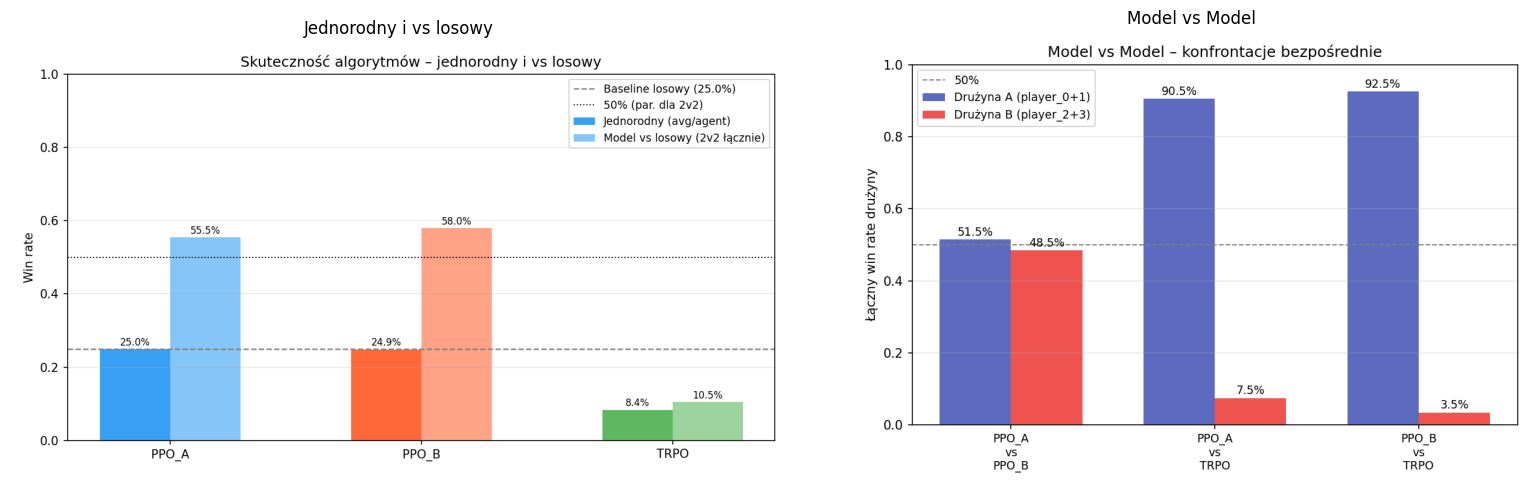

In [24]:
import matplotlib.pyplot as plt, matplotlib.image as mpimg, os

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, fname, title in [
    (axes[0], "results/plots/win_rates.png",      "Jednorodny i vs losowy"),
    (axes[1], "results/plots/model_vs_model.png", "Model vs Model"),
]:
    if os.path.exists(fname):
        ax.imshow(mpimg.imread(fname))
        ax.axis("off")
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f"Brak {fname}", ha="center", va="center")
        ax.axis("off")

plt.tight_layout()
plt.show()

Gdy 4 gracze byli z tego samego algorytmu, w przypadku PPO_A i PPO_B praktycznie nie dochodziło do timeoutów; natomiast TRPO wygrywał rzadko jakikolwiek agent. Gdy były przeciwstawione przeciwko agentom losowym widać, że PPO_A i PPO_B wygrywają częściej od nich (nie zawsze, ponieważ w makao liczy się też łut szcześcia), natomiast TRPO wygrywał 5 razy rzadziej, bo tylko w 10,5% przypadków. Kiedy zostaną przeciwstawione poszczególne algorytmy, to wyniki są dość ciekawe: choć PPO_A wygrywa rzadziej przeciwko agentom losowym niż PPO_B (55,5% vs 58%), to wygrywa z nim częściej (51,5%). Wtedy nie ma żadnych timeoutów. TRPO przegrywa z PPO_A i PPO_B w przeważającej liczbie przypadków.